# 01-7 全双工多模态：听懂你的声音，用声音回答

在前几节中，我们分别探索了图片、视频、声音如何变成 Token。但真实的多模态交互不是"单行道" —— 我们希望模型能**同时听和说**，就像和人对话一样。

本节我们将串联所有模态，体验全双工多模态交互的完整流程：
- 🖼️ **图片理解**：Qwen3.5 看懂乖乖图片
- 🎬 **视频理解**：Qwen3.5 理解吉卜力风格视频
- 🎤 **语音识别**：Whisper 将语音转为文字
- 🔊 **语音合成**：edge-tts 将文字转为语音

整个流程：**语音提问 → Whisper 识别 → Qwen3.5 看图推理 → edge-tts 语音回答**

> 💡 **关于 MiniCPM-o**：面壁智能的 MiniCPM-o-4_5 是一个原生支持全双工多模态交互的模型（图片+视频+语音理解+语音生成一体化）。由于它对 transformers 版本有特殊要求，本节使用更通用的组件组合方案来演示相同的概念。在 [MiniCPM-o 官方仓库](https://github.com/OpenBMB/MiniCPM-o) 可以找到完整的使用指南。

In [1]:
from modelscope import snapshot_download
from transformers import AutoTokenizer, AutoProcessor, Qwen3_5ForConditionalGeneration, TextIteratorStreamer
from PIL import Image
import torch
import matplotlib.pyplot as plt
import numpy as np
import os
import logging
from threading import Thread

logging.getLogger("transformers").setLevel(logging.ERROR)
logging.getLogger("modelscope").setLevel(logging.ERROR)

plt.rcParams['font.sans-serif'] = ['Arial Unicode MS', 'SimHei', 'PingFang SC']
plt.rcParams['axes.unicode_minus'] = False

NOTEBOOK_DIR = os.path.dirname(os.path.abspath('__file__')) if '__file__' in dir() else os.getcwd()

tokenizer_id = "Qwen/Qwen3.5-0.8B"
model_dir = snapshot_download(tokenizer_id)
tokenizer = AutoTokenizer.from_pretrained(model_dir, local_files_only=True)
processor = AutoProcessor.from_pretrained(model_dir, local_files_only=True)
model = Qwen3_5ForConditionalGeneration.from_pretrained(model_dir, local_files_only=True)
config = model.config

print(f"Qwen3.5 模型加载完成: {tokenizer_id}")

import whisper
import warnings
warnings.filterwarnings("ignore", message="FP16 is not supported on CPU")

print("加载 Whisper 模型 (tiny)...")
whisper_model = whisper.load_model("tiny")
print("Whisper 模型加载完成！")

import edge_tts
import asyncio
import nest_asyncio
nest_asyncio.apply()
from IPython.display import Audio, display

async def text_to_speech(text, output_path, voice="zh-CN-XiaoxiaoNeural"):
    communicate = edge_tts.Communicate(text, voice)
    await communicate.save(output_path)
    return output_path

print("edge-tts 就绪！")
print("\n全双工多模态组件全部加载完成：Qwen3.5 (看图/视频) + Whisper (听声音) + edge-tts (说话)")

Loading weights:   0%|          | 0/473 [00:00<?, ?it/s]

Qwen3.5 模型加载完成: Qwen/Qwen3.5-0.8B
加载 Whisper 模型 (tiny)...


Whisper 模型加载完成！
edge-tts 就绪！

全双工多模态组件全部加载完成：Qwen3.5 (看图/视频) + Whisper (听声音) + edge-tts (说话)


## 1. 图片理解：Qwen3.5 看懂乖乖

让我们先用乖乖图片测试 Qwen3.5 的图片理解能力。Qwen3.5 使用 ViT 视觉编码器，将图片切分为 Patch 后编码为视觉 Token，然后与文本 Token 一起输入 Transformer 处理。

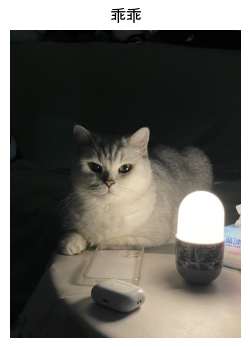

提问: 你从图里看到了什么？挑重点，禁止啰嗦 /no_think
输入 Token 数: 367

Qwen3.5 回答: 

图片

中

有一只

灰

...

柔和

的光

晕

。



生成耗时 283.3s


In [2]:
demo_img_path = os.path.join(NOTEBOOK_DIR, "guaiguai.jpg")
demo_img = Image.open(demo_img_path)

plt.figure(figsize=(4, 4))
plt.imshow(demo_img)
plt.title("乖乖")
plt.axis('off')
plt.show()

question = "你从图里看到了什么？挑重点，禁止啰嗦 /no_think"
messages = [
    {
        "role": "user",
        "content": [
            {"type": "image", "image": demo_img},
            {"type": "text", "text": question},
        ],
    }
]

inputs = processor.apply_chat_template(
    messages,
    tokenize=True,
    add_generation_prompt=True,
    return_dict=True,
    return_tensors="pt",
)

print(f"提问: {question}")
print(f"输入 Token 数: {inputs['input_ids'].numel()}")
print(f"\nQwen3.5 回答: ", end="", flush=True)

streamer = TextIteratorStreamer(tokenizer, skip_prompt=True, skip_special_tokens=True)
generation_kwargs = dict(
    **inputs,
    streamer=streamer,
    max_new_tokens=256,
    temperature=0.7,
    top_p=0.8,
    top_k=20,
    repetition_penalty=1.0,
    do_sample=True,
)

import time
t0 = time.time()

thread = Thread(target=model.generate, kwargs=generation_kwargs)
thread.start()

image_answer = ""
for new_text in streamer:
    print(new_text, end="", flush=True)
    image_answer += new_text

thread.join()
elapsed = time.time() - t0
print(f"\n生成耗时 {elapsed:.1f}s")

## 2. 视频理解：Qwen3.5 看懂吉卜力风格视频

Qwen3.5 也支持视频输入。视频的 Token 化引入了时间维度，每 2 帧合并为一个时间 Patch，再和空间 Patch 一起编码。

In [3]:
video_path = os.path.join(NOTEBOOK_DIR, "guaiguai_ghibli_film.mp4")
print(f"视频文件: {video_path}")

question = "视频里发生了什么？挑重点，禁止啰嗦 /no_think"
messages_v = [
    {
        "role": "user",
        "content": [
            {"type": "video", "video": video_path},
            {"type": "text", "text": question},
        ],
    }
]

inputs_v = processor.apply_chat_template(
    messages_v,
    tokenize=True,
    add_generation_prompt=True,
    return_dict=True,
    return_tensors="pt",
)

n_video_tok = (inputs_v["input_ids"] == config.video_token_id).sum().item()
print(f"提问: {question}")
print(f"视频 Token 数量: {n_video_tok}")
print(f"\nQwen3.5 回答: ", end="", flush=True)

streamer_v = TextIteratorStreamer(tokenizer, skip_prompt=True, skip_special_tokens=True)
generation_kwargs_v = dict(
    **inputs_v,
    streamer=streamer_v,
    max_new_tokens=256,
    temperature=0.7,
    top_p=0.8,
    top_k=20,
    repetition_penalty=1.0,
    do_sample=True,
)

t0_v = time.time()

thread_v = Thread(target=model.generate, kwargs=generation_kwargs_v)
thread_v.start()

video_answer = ""
for new_text in streamer_v:
    print(new_text, end="", flush=True)
    video_answer += new_text

thread_v.join()
elapsed_v = time.time() - t0_v
print(f"\n生成耗时 {elapsed_v:.1f}s")

视频文件: /Users/rongtao/Desktop/LLMPrimer/01-token_journey/guaiguai_ghibli_film.mp4
提问: 视频里发生了什么？挑重点，禁止啰嗦 /no_think
视频 Token 数量: 1664

Qwen3.5 回答: 

视频中

展示

了一只

白

...

和

怀旧

的感觉

。



生成耗时 573.4s


## 3. 语音识别：Whisper 听懂你的声音

Whisper 是 OpenAI 开源的语音识别模型，它将音频波形 → 分帧 → Mel 频谱 → Transformer 编码器 → 文字。这就是"音频输入"的完整链路：声音 → Token → 文字。

我们先用 edge-tts 生成一段测试语音，然后用 Whisper 识别：

In [4]:
demo_text = "你好，请问图片里的猫咪在做什么？"
tts_path = os.path.join(NOTEBOOK_DIR, "demo_question.wav")

print(f"TTS 生成测试语音: {demo_text!r}")
await text_to_speech(demo_text, tts_path)
print(f"语音已保存: {tts_path}")

display(Audio(tts_path))

print(f"\nWhisper 识别中...")
result = whisper_model.transcribe(tts_path, language="zh")
asr_text = result['text'].strip()
print(f"识别结果: {asr_text!r}")

TTS 生成测试语音: '你好，请问图片里的猫咪在做什么？'


语音已保存: /Users/rongtao/Desktop/LLMPrimer/01-token_journey/demo_question.wav



Whisper 识别中...


识别结果: '你好 请问图片里的猫咪在做什么'


## 4. 语音合成：edge-tts 用声音回答

TTS 是 ASR 的逆过程：文字 → 音频 Token → 声音波形。我们使用微软开源的 edge-tts 来演示：

In [5]:
tts_text = "你好！我是Qwen多模态模型，我能看图说话，也能听懂你的声音！"
print(f"TTS 输入: {tts_text!r}")

tts_output_path = os.path.join(NOTEBOOK_DIR, "tts_output.wav")
await text_to_speech(tts_text, tts_output_path)
print(f"语音已保存: {tts_output_path}")

display(Audio(tts_output_path))

TTS 输入: '你好！我是Qwen多模态模型，我能看图说话，也能听懂你的声音！'


语音已保存: /Users/rongtao/Desktop/LLMPrimer/01-token_journey/tts_output.wav


## 5. 全双工交互：语音提问 → 看图推理 → 语音回答

现在我们把所有模块串起来：用 TTS 模拟语音提问，Whisper 识别，Qwen3.5 看乖乖图片后回答，然后用语音播放回答！这就是全双工多模态交互的完整流程。

> 💡 如果你在本地 Jupyter 中运行，可以把 TTS 模拟改为 `sounddevice` 录音，实现真正的语音交互。

模拟语音提问: '请描述这张图片里的猫咪'


模拟语音已保存: /Users/rongtao/Desktop/LLMPrimer/01-token_journey/user_recording.wav



Whisper 识别中...
识别结果: '請描述這張圖片裡的貓咪'


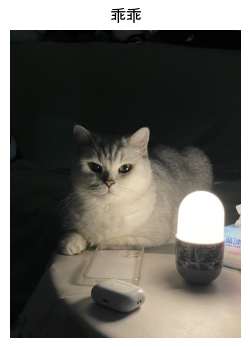


你的问题: 請描述這張圖片裡的貓咪
Qwen3.5 回答: 

這張

圖片

中

，一隻

...

感的

畫面

。



生成耗时 804.9s

将回答转为语音...


语音已生成: /Users/rongtao/Desktop/LLMPrimer/01-token_journey/response_audio.wav


In [6]:
simulated_question = "请描述这张图片里的猫咪"
print(f"模拟语音提问: {simulated_question!r}")

record_path = os.path.join(NOTEBOOK_DIR, "user_recording.wav")
await text_to_speech(simulated_question, record_path)
print(f"模拟语音已保存: {record_path}")

display(Audio(record_path))

print(f"\nWhisper 识别中...")
result = whisper_model.transcribe(record_path, language="zh")
user_question = result['text'].strip()
print(f"识别结果: {user_question!r}")

if not user_question:
    print(f"\n未检测到语音，使用默认问题: \"请描述这张图片\"")
    user_question = "请描述这张图片"

demo_img_path = os.path.join(NOTEBOOK_DIR, "guaiguai.jpg")
demo_img = Image.open(demo_img_path)

plt.figure(figsize=(4, 4))
plt.imshow(demo_img)
plt.title("乖乖")
plt.axis('off')
plt.show()

messages_i = [
    {
        "role": "user",
        "content": [
            {"type": "image", "image": demo_img},
            {"type": "text", "text": user_question + " /no_think"},
        ],
    }
]

inputs_i = processor.apply_chat_template(
    messages_i,
    tokenize=True,
    add_generation_prompt=True,
    return_dict=True,
    return_tensors="pt",
)

print(f"\n你的问题: {user_question}")
print(f"Qwen3.5 回答: ", end="", flush=True)

streamer_i = TextIteratorStreamer(tokenizer, skip_prompt=True, skip_special_tokens=True)
generation_kwargs_i = dict(
    **inputs_i,
    streamer=streamer_i,
    max_new_tokens=256,
    temperature=0.7,
    top_p=0.8,
    top_k=20,
    repetition_penalty=1.0,
    do_sample=True,
)

t0_i = time.time()

thread_i = Thread(target=model.generate, kwargs=generation_kwargs_i)
thread_i.start()

generated_text = ""
for new_text in streamer_i:
    print(new_text, end="", flush=True)
    generated_text += new_text

thread_i.join()
elapsed_i = time.time() - t0_i
print(f"\n生成耗时 {elapsed_i:.1f}s")

response_text = generated_text.strip()

print(f"\n将回答转为语音...")
response_audio_path = os.path.join(NOTEBOOK_DIR, "response_audio.wav")
await text_to_speech(response_text, response_audio_path)
print(f"语音已生成: {response_audio_path}")

display(Audio(response_audio_path))

## 小结

本节我们用 Qwen3.5 + Whisper + edge-tts 体验了全双工多模态交互：

| 能力 | 组件 | 输入 | 输出 |
|------|------|------|------|
| 图片理解 | Qwen3.5 | PIL Image | 文本 |
| 视频理解 | Qwen3.5 | 视频文件 | 文本 |
| 语音识别 | Whisper | 音频波形 | 文本 |
| 语音合成 | edge-tts | 文本 | 音频波形 |
| 全双工交互 | 全部组合 | 图片+语音 | 文本+语音 |

核心洞察：**全双工多模态 = 所有模态的 Token 在同一个 Transformer 中统一处理。** 无论是 Qwen3.5 的视觉 Token，还是 Whisper 的音频 Token，最终都被映射到同一个向量空间，作为统一的 Token 序列输入 Transformer。这就是"万物皆 Token"的真正含义。

💡 **进阶**：如果想体验原生全双工多模态（图片+视频+语音理解+语音生成一体化），可以尝试 [MiniCPM-o-4_5](https://github.com/OpenBMB/MiniCPM-o)，它将所有模态统一在一个模型中，无需组合多个组件。

回顾整个多模态 Token 系列：
- [01-4 图片怎么变成 Token](./01-4-image_to_token.ipynb)：ViT Patch 切分 + 空间合并
- [01-5 视频怎么变成 Token](./01-5-video_to_token.ipynb)：时间 Patch + 空间合并
- [01-6 声音怎么变成 Token](./01-6-audio_to_token.ipynb)：分帧 + RVQ 编解码
- **01-7 全双工多模态**：所有模态统一交互